In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import pickle

## Importing Dataset

In [87]:
df = pd.read_csv('app_dataset_final.csv')

In [3]:
df.head()

,Name,Category
0,RTO Vehicle Information,Auto & Vehicles
1,"Vahak: Book Online Truck, Load",Auto & Vehicles
2,"CARS24® – Buy Used Cars Online, Sell Car in 1 ...",Auto & Vehicles
3,BlackBuck Boss,Auto & Vehicles
4,CarDekho:New & Second Hand Car,Auto & Vehicles


## Data Analysis and Preprocessing

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22952 entries, 0 to 25368
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      22952 non-null  object
 1   Category  22952 non-null  object
dtypes: object(2)
memory usage: 537.9+ KB


In [12]:
df.shape

(22952, 2)

### Handling Null Values

In [5]:
df.isnull().sum()

Name        0
Category    0
dtype: int64

##### No null values are present in dataset

### Handling Duplicate Values

In [6]:
df.duplicated().sum()

np.int64(2417)

In [88]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

##### Dropping duplicates are safe because they are due to data collection redundancy

## Data Distribution

In [17]:
print(df['Category'].value_counts())

Category
FAMILY          1909
GAME             960
TOOLS            829
Shopping         501
Business         500
                ... 
Weather            9
Art & Design       3
Dating             3
House & Home       2
1.9                1
Name: count, Length: 66, dtype: int64


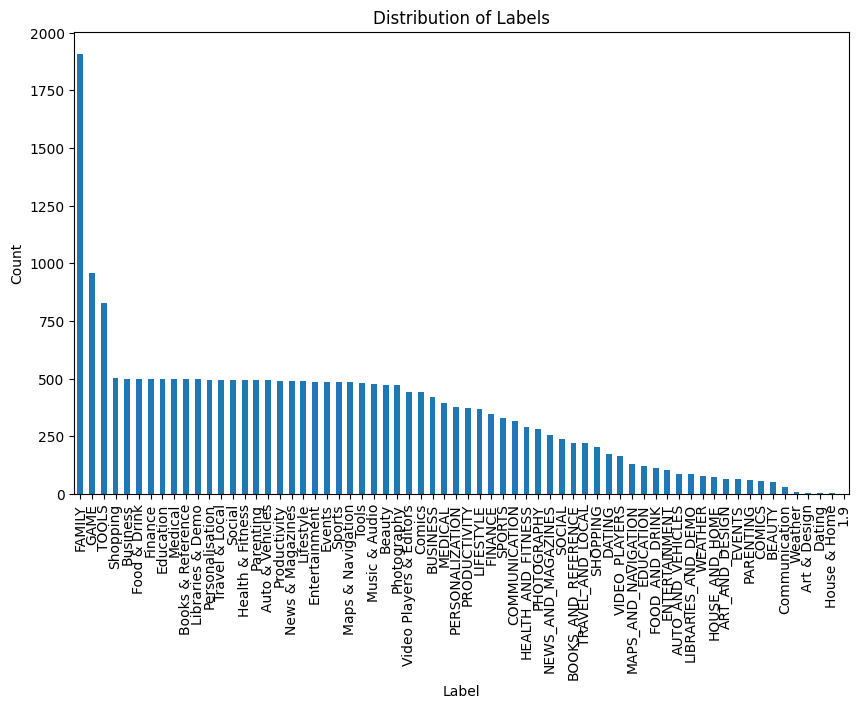

In [43]:
plt.figure(figsize=(10, 6))
df['Category'].value_counts().plot(kind='bar')

plt.xlabel('Label') 
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.show()

## Removing Wrong Labels

In [89]:
df = df[df['Category'] != '1.9']

In [45]:
print(df['Category'].value_counts())

Category
FAMILY           1909
GAME              960
TOOLS             829
Shopping          501
Business          500
                 ... 
Communication      28
Weather             9
Art & Design        3
Dating              3
House & Home        2
Name: count, Length: 65, dtype: int64


## Category Grouping

In [46]:
df['Category'].unique()

array(['Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Education', 'Entertainment', 'Events', 'Finance',
       'Food & Drink', 'Health & Fitness', 'Libraries & Demo',
       'Lifestyle', 'Maps & Navigation', 'Medical', 'Music & Audio',
       'News & Magazines', 'Parenting', 'Personalisation', 'Photography',
       'Productivity', 'Shopping', 'Social', 'Sports', 'Tools',
       'Travel & Local', 'Video Players & Editors', 'Communication',
       'Art & Design', 'Dating', 'Weather', 'House & Home',
       'ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING

#### Normalizing 

In [90]:
df['Category'] = df['Category'].str.upper().str.replace('&', 'AND').str.replace(' ', '_')

In [91]:
category_mapping = {

    #  HIGH RISK / SENSITIVE
    'DATING': 'Sensitive',
    'PARENTING': 'Sensitive',   # (can contain unsafe content for kids if misused)

    #  SOCIAL / COMMUNICATION (High interaction)
    'SOCIAL': 'Social',
    'COMMUNICATION': 'Social',

    #  GAMES
    'GAME': 'Games',

    #  EDUCATION / LEARNING (SAFE)
    'EDUCATION': 'Education',
    'BOOKS_AND_REFERENCE': 'Education',
    'LIBRARIES_AND_DEMO': 'Education',

    #  MEDIA ENTERTAINMENT (MEDIUM RISK)
    'ENTERTAINMENT': 'Entertainment',
    'VIDEO_PLAYERS': 'Entertainment',
    'VIDEO_PLAYERS_AND_EDITORS': 'Entertainment',
    'MUSIC_AND_AUDIO': 'Entertainment',
    'COMICS': 'Entertainment',

    #  LIGHT ENTERTAINMENT / SPORTS (separate for clarity)
    'SPORTS': 'Entertainment',

    #  TOOLS / PRODUCTIVITY (LOW RISK)
    'TOOLS': 'Tools',
    'PRODUCTIVITY': 'Tools',

    #  BUSINESS / FINANCE (NEUTRAL but not kid-focused)
    'BUSINESS': 'Other',
    'FINANCE': 'Other',

    #  INFORMATION / UTILITIES (separate from junk “Other”)
    'NEWS_AND_MAGAZINES': 'Other',
    'WEATHER': 'Other',
    'MAPS_AND_NAVIGATION': 'Other',

    #  LIFESTYLE / COMMERCE
    'SHOPPING': 'Other',
    'LIFESTYLE': 'Other',
    'FOOD_AND_DRINK': 'Other',
    'TRAVEL_AND_LOCAL': 'Other',

    #  MEDIA CREATION
    'PHOTOGRAPHY': 'Other',
    'ART_AND_DESIGN': 'Other',

    #  SENSITIVE REAL-WORLD DOMAINS
    'HEALTH_AND_FITNESS': 'Other',
    'MEDICAL': 'Sensitive',   # ⚠ important for child safety context

    #  SYSTEM / DEVICE / RANDOM
    'HOUSE_AND_HOME': 'Other',
    'AUTO_AND_VEHICLES': 'Other',
    'EVENTS': 'Other',
    'BEAUTY': 'Other',

    #  SPECIAL CASE
    'PERSONALIZATION': 'Other',
    'FAMILY': 'Other'
}

In [92]:
df['Category'] = df['Category'].map(category_mapping)

In [93]:
df['Category'].unique()

array(['Other', 'Education', 'Entertainment', 'Sensitive', nan, 'Tools',
       'Social', 'Games'], dtype=object)

In [94]:
df.isnull().sum()

Name          0
Category    496
dtype: int64

In [95]:
df['Category'] = df['Category'].fillna('Other')

In [96]:
df['Category'].unique()

array(['Other', 'Education', 'Entertainment', 'Sensitive', 'Tools',
       'Social', 'Games'], dtype=object)

## Pre-processing Funcion

In [97]:
def preprocess_app_name(text):
    """
    Clean app names for ML pipeline (training + prediction)
    """
    if pd.isnull(text):
        return ""

    # 1. lowercase
    text = text.lower()

    # 2. remove special characters (keep letters, numbers, space)
    text = re.sub(r'[^a-z0-9 ]', ' ', text)

    # 3. remove digits (optional but recommended for app names)
    text = re.sub(r'\d+', ' ', text)

    # 4. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [98]:
df['Name'] = df['Name'].apply(preprocess_app_name)

## Separation of Dependent and Independent Variables

In [99]:
x=df['Name']
y=df['Category']

## Train Test Splitting 

In [100]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
x_train.shape

(18360,)

In [36]:
y_train.shape

(18360,)

## Label Encoding

In [101]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

## Defining Tf-idf (Vectorizer) + Model Training

In [107]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_app_name,   # ok if raw text input
        analyzer='char',
        ngram_range=(2,5),         # 🔥 better for app names
        max_features=10000
    )),

    ("model", LogisticRegression(
         class_weight='balanced'
    ))
])

In [108]:
pipeline.fit(x_train,y_train_encoded)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,<function pre...0024DAB8DA830>
,tokenizer,None


## Model Prediction

In [109]:
y_pred = pipeline.predict(x_test)

In [110]:
accuracy_score(y_test_encoded,y_pred)

0.6068394685253757

In [111]:
confusion_matrix(y_test_encoded,y_pred)

array([[ 216,   36,   19,   33,   22,   12,   36],
       [  38,  394,   47,   57,   11,   32,   27],
       [   3,   18,  124,   22,    2,    7,    7],
       [ 177,  176,  172, 1420,  159,  107,  231],
       [  18,    8,    9,   30,  236,   13,   15],
       [   6,   18,    8,   25,   11,  138,   19],
       [  20,   17,   16,   58,   16,   47,  258]])

- all 7 classes are being learned
- no class is ignored
- distribution fairly balanced

## Model Saving

In [113]:
with open("AppAnalysisModel.pkl", "wb") as f:
    pickle.dump(pipeline, f)